Saving vrsu lab 8.jpg to vrsu lab 8.jpg


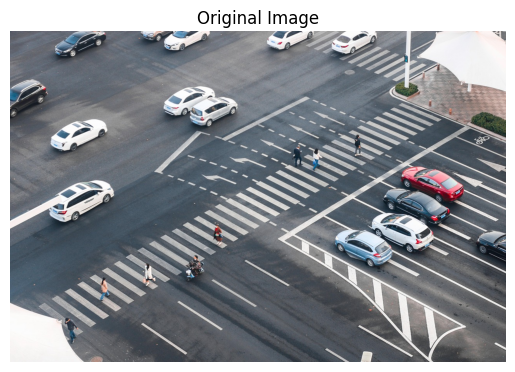

Running Semantic Segmentation...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 98.7MB/s]


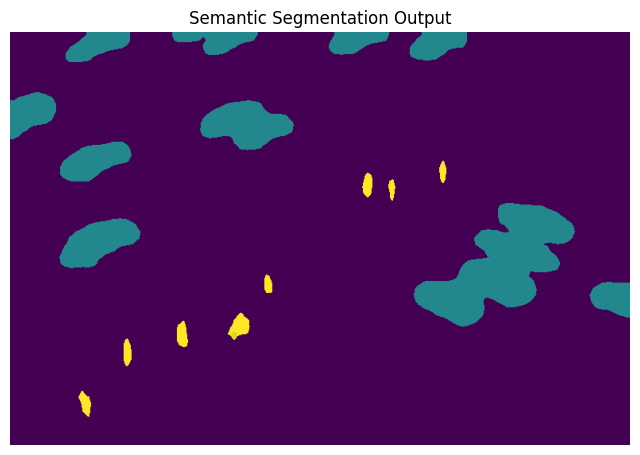

Running Instance Segmentation...
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 102MB/s]


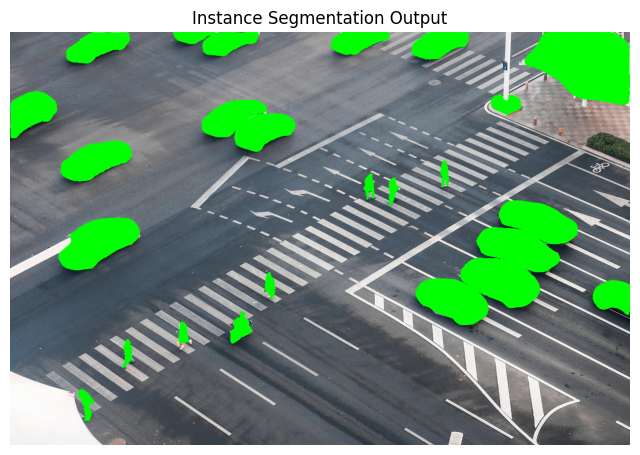

In [2]:
# =========================================
# 1. Install Required Libraries
# =========================================
!pip install torch torchvision matplotlib pillow opencv-python -q

# =========================================
# 2. Import Libraries
# =========================================
import torch
import torchvision.transforms as T
import torchvision.models as models
import torchvision.models.detection as detection
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files

# =========================================
# 3. Upload Image
# =========================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# =========================================
# PART 1: SEMANTIC SEGMENTATION (DeepLabV3)
# =========================================
print("Running Semantic Segmentation...")

# Load pretrained model (updated method)
semantic_model = models.segmentation.deeplabv3_resnet101(weights="DEFAULT")
semantic_model.eval()

# Transform image
transform = T.Compose([
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(image).unsqueeze(0)

# Run model
with torch.no_grad():
    output = semantic_model(input_tensor)["out"][0]

# Get segmentation mask
semantic_mask = output.argmax(0).byte().cpu().numpy()

# Show result
plt.figure(figsize=(8,6))
plt.imshow(semantic_mask)
plt.title("Semantic Segmentation Output")
plt.axis("off")
plt.show()

# =========================================
# PART 2: INSTANCE SEGMENTATION (Mask R-CNN)
# =========================================
print("Running Instance Segmentation...")

# Load pretrained model
instance_model = detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
instance_model.eval()

# Convert image
img_tensor = T.ToTensor()(image)

# Run model
with torch.no_grad():
    predictions = instance_model([img_tensor])

# Convert image to OpenCV format
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Apply masks
for i in range(len(predictions[0]['masks'])):

    score = predictions[0]['scores'][i]

    if score > 0.5:
        mask = predictions[0]['masks'][i, 0].mul(255).byte().cpu().numpy()
        image_cv[mask > 127] = [0, 255, 0]  # Green mask

# Show output
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.title("Instance Segmentation Output")
plt.axis("off")
plt.show()